In [1]:
DATASET_PATH = "/content/Train_Test_Windows_10(in).csv"  # UPDATE THIS
SEQUENCE_LENGTH = 10
RANDOM_STATE = 42
TEST_SIZE = 0.2


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Import necessary library
from sklearn.model_selection import train_test_split


print("Loading data...")
df = pd.read_csv(DATASET_PATH)
df['attack'] = df['label'].apply(lambda x: 1 if x == 'dos' else 0)
numeric_cols = df.select_dtypes(include=np.number).columns.drop('attack')
df[numeric_cols] = df[numeric_cols].fillna(0)

scaler = MinMaxScaler()
X = scaler.fit_transform(df[numeric_cols])
y = df['attack'].values

# Create sequences
X_seq, y_seq = [], []
for i in range(len(X) - SEQUENCE_LENGTH):
    X_seq.append(X[i:i+SEQUENCE_LENGTH])
    y_seq.append(y[i+SEQUENCE_LENGTH])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print("\nData prepared:")
print(f"- Training sequences: {X_train.shape}")
print(f"- Test sequences: {X_test.shape}")
print(f"- Attack ratio: {y_train.mean():.2%} (train), {y_test.mean():.2%} (test)")


Loading data...

Data prepared:
- Training sequences: (16875, 10, 56)
- Test sequences: (4219, 10, 56)
- Attack ratio: 0.00% (train), 0.00% (test)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LENGTH, len(numeric_cols))),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining LSTM...")
history = model.fit(X_train, y_train,
                   epochs=10,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9939 - loss: 0.0481 - val_accuracy: 1.0000 - val_loss: 5.4057e-05
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 1.0000 - loss: 6.8076e-05 - val_accuracy: 1.0000 - val_loss: 2.2448e-05
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 1.0000 - loss: 3.3049e-05 - val_accuracy: 1.0000 - val_loss: 1.3560e-05
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 1.0000 - loss: 2.1494e-05 - val_accuracy: 1.0000 - val_loss: 9.2034e-06
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 1.5148e-05 - val_accuracy: 1.0000 - val_loss: 6.6000e-06
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 1.1439e-05 - val_accuracy: 1.0000 - val_loss: 4.9147e-06
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 1.0000 - loss: 8.6595e-06 - val_accuracy: 1.0000 - val_loss: 3.7164e-06
Epoch 8/10
422/422 ━━━━━━━━━━━

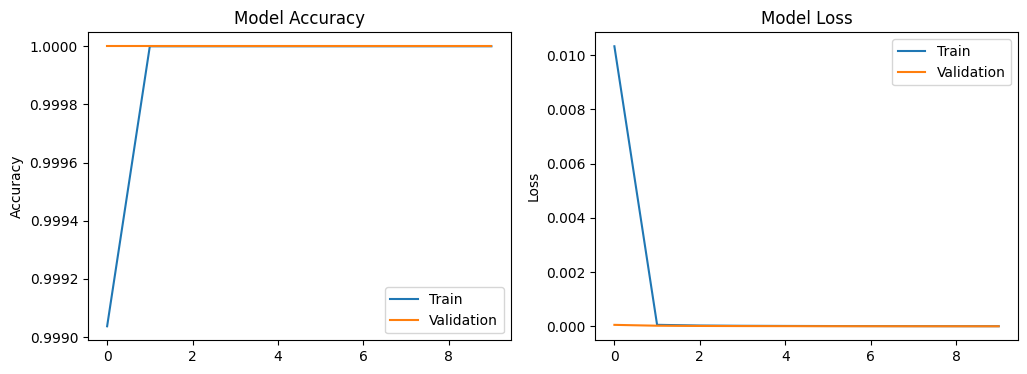

In [5]:
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
# Evaluate
from sklearn.metrics import classification_report
y_pred_lstm = (model.predict(X_test) > 0.5).astype(int)
print("\nLSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4219

    accuracy                           1.00      4219
   macro avg       1.00      1.00      1.00      4219
weighted avg       1.00      1.00      1.00      4219



In [8]:
from sklearn.ensemble import RandomForestClassifier

print("\nTraining Random Forest...")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_flat, y_train)

y_pred_rf = rf.predict(X_test_flat)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest...

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4219

    accuracy                           1.00      4219
   macro avg       1.00      1.00      1.00      4219
weighted avg       1.00      1.00      1.00      4219




Running Feature Ablation Study...
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


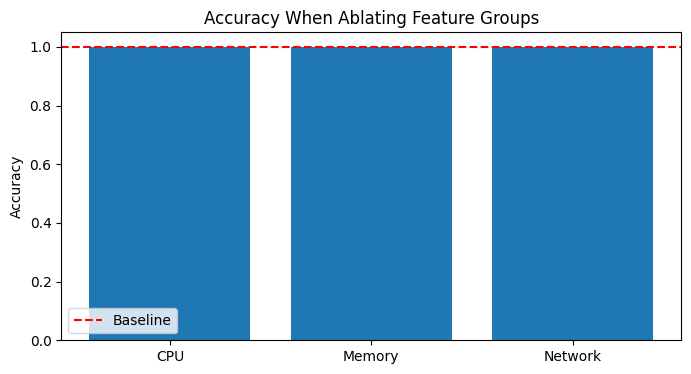

In [10]:
from sklearn.metrics import accuracy_score
print("\nRunning Feature Ablation Study...")
categories = {
    'CPU': [i for i,col in enumerate(numeric_cols) if 'Processor' in col],
    'Memory': [i for i,col in enumerate(numeric_cols) if 'Memory' in col],
    'Network': [i for i,col in enumerate(numeric_cols) if 'Network' in col]
}

baseline_acc = accuracy_score(y_test, y_pred_lstm)
ablation_results = {}

for name, indices in categories.items():
    X_ablated = X_test.copy()
    X_ablated[:,:,indices] = 0  # Zero out feature group
    y_pred = (model.predict(X_ablated) > 0.5).astype(int)
    ablation_results[name] = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,4))
plt.bar(ablation_results.keys(), ablation_results.values())
plt.axhline(y=baseline_acc, color='r', linestyle='--', label='Baseline')
plt.title("Accuracy When Ablating Feature Groups")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
lstm_scores = [
    accuracy_score(y_test, y_pred_lstm),
    precision_score(y_test, y_pred_lstm),
    recall_score(y_test, y_pred_lstm),
    f1_score(y_test, y_pred_lstm)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py

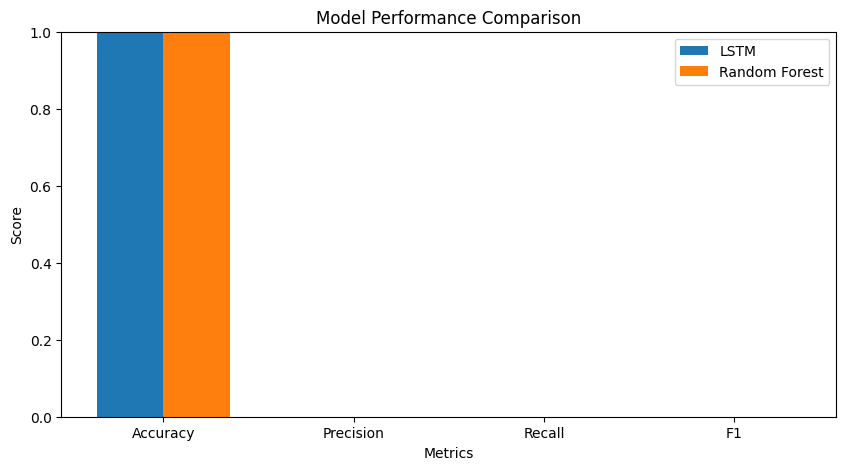

In [13]:
plt.figure(figsize=(10,5))
plt.bar(x - width/2, lstm_scores, width, label='LSTM')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [14]:
import joblib

model.save('lstm_attack_model_2.h5')
joblib.dump(rf, 'random_forest_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("\nModels saved:")
print("- LSTM: lstm_attack_model.h5")
print("- Random Forest: random_forest_model.joblib")
print("- Scaler: scaler.joblib")


Models saved:
- LSTM: lstm_attack_model.h5
- Random Forest: random_forest_model.joblib
- Scaler: scaler.joblib


Loading saved models...

Loading original dataset...

Making predictions...
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

LSTM PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21094

    accuracy                           1.00     21094
   macro avg       1.00      1.00      1.00     21094
weighted avg       1.00      1.00      1.00     21094

Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py

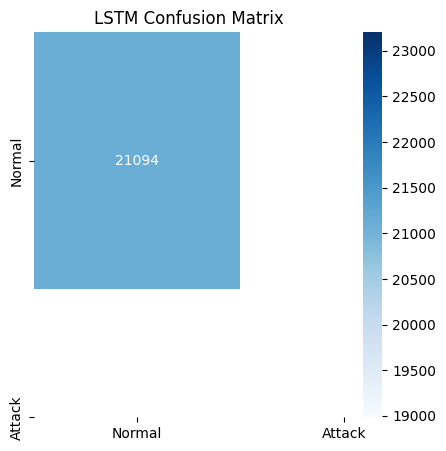


RANDOM FOREST PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21094

    accuracy                           1.00     21094
   macro avg       1.00      1.00      1.00     21094
weighted avg       1.00      1.00      1.00     21094

Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py

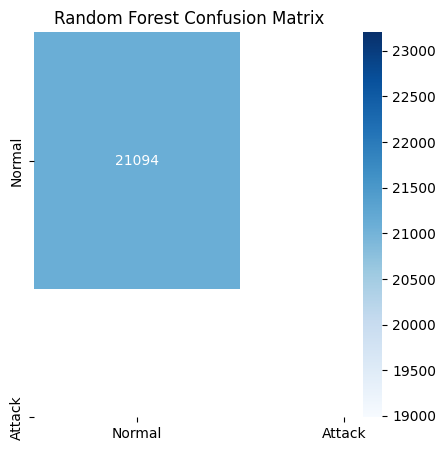

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py

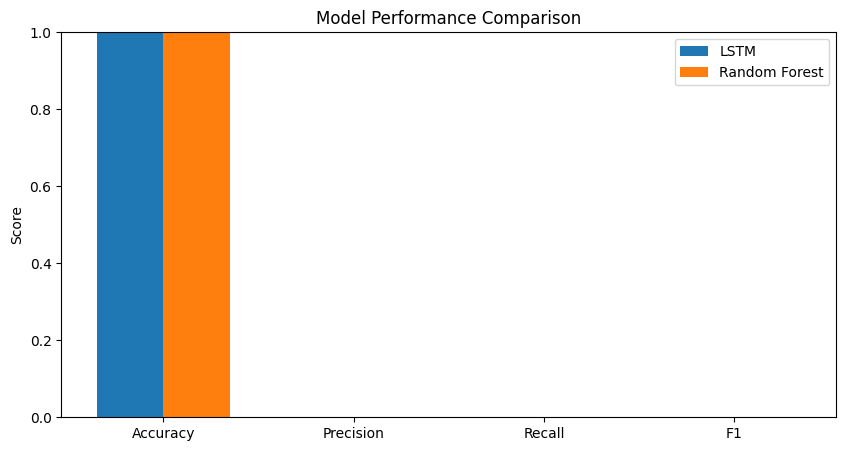


Prediction Samples:
 Sample Actual LSTM_Pred LSTM_Prob RF_Pred
  12225 Normal    Normal    0.0000  Normal
   3449 Normal    Normal    0.0000  Normal
   1426 Normal    Normal    0.0000  Normal
  17515 Normal    Normal    0.0000  Normal
  20790 Normal    Normal    0.0000  Normal


In [18]:
# TESTING WITH EXISTING DATASET
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import joblib
from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Saved Models and Scaler
print("Loading saved models...")
lstm_model = load_model('lstm_attack_model_2.h5')
rf_model = joblib.load('random_forest_model.joblib')
scaler = joblib.load('scaler.joblib')

# 2. Load Original Dataset
print("\nLoading original dataset...")
df = pd.read_csv("/content/Train_Test_Windows_10(in).csv")  # Update path if needed
df['attack'] = df['label'].apply(lambda x: 1 if x == 'dos' else 0)
numeric_cols = df.select_dtypes(include=np.number).columns.drop('attack')

# 3. Prepare Data (same as training)
X = scaler.transform(df[numeric_cols])
y = df['attack'].values

# Create sequences
X_seq, y_seq = [], []
for i in range(len(X) - 10):  # Using 10 timesteps
    X_seq.append(X[i:i+10])
    y_seq.append(y[i+10])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# 4. Make Predictions
print("\nMaking predictions...")
# LSTM
lstm_probs = lstm_model.predict(X_seq)
lstm_preds = (lstm_probs > 0.5).astype(int)

# Random Forest (flatten sequences)
X_flat = X_seq.reshape(X_seq.shape[0], -1)
rf_preds = rf_model.predict(X_flat)

# 5. Evaluate Performance
def evaluate_performance(y_true, y_pred, model_name):
    print(f"\n{model_name.upper()} PERFORMANCE")
    print("="*50)
    print(classification_report(y_true, y_pred))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")

    # Confusion Matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

evaluate_performance(y_seq, lstm_preds, "LSTM")
evaluate_performance(y_seq, rf_preds, "Random Forest")

# 6. Model Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
lstm_scores = [
    accuracy_score(y_seq, lstm_preds),
    precision_score(y_seq, lstm_preds),
    recall_score(y_seq, lstm_preds),
    f1_score(y_seq, lstm_preds)
]
rf_scores = [
    accuracy_score(y_seq, rf_preds),
    precision_score(y_seq, rf_preds),
    recall_score(y_seq, rf_preds),
    f1_score(y_seq, rf_preds)
]

plt.figure(figsize=(10,5))
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, lstm_scores, width, label='LSTM')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

# 7. Prediction Samples
print("\nPrediction Samples:")
sample_indices = np.random.choice(len(X_seq), 5, replace=False)
results = []
for idx in sample_indices:
    actual = y_seq[idx]
    lstm_prob = lstm_probs[idx][0]
    rf_pred = rf_preds[idx]
    results.append({
        'Sample': idx,
        'Actual': 'Attack' if actual == 1 else 'Normal',
        'LSTM_Pred': 'Attack' if lstm_prob > 0.5 else 'Normal',
        'LSTM_Prob': f"{lstm_prob:.4f}",
        'RF_Pred': 'Attack' if rf_pred == 1 else 'Normal'
    })

print(pd.DataFrame(results).to_string(index=False))